In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:
# Results generated by our library
csv_our = pd.read_csv("results_our/results_our.csv")

# Results generated by the reference library
csv_ref = pd.read_csv("results_ref/results_ref.csv")

In [23]:
keys = ["dgp", "statistic", "method", "n", "B", "repetitions"]

# Merge the datasets so we can analyze the same cases together
comparison = csv_our.merge(
    csv_ref,
    on=keys,
    suffixes=("_our", "_ref"),
    validate="one_to_one",
)

assert len(comparison) == len(csv_ref) and len(comparison) == len(csv_our), (
    "Experiments don't match!"
)

comparison.head(5)

,method,nominal_1_sided_coverage_our,nominal_2_sided_coverage_our,lower_coverage_conditional_our,upper_coverage_conditional_our,two_sided_coverage_conditional_our,two_sided_coverage_our,mean_two_sided_length_conditional_our,median_two_sided_length_conditional_our,lower_bound_success_rate_our,...,nominal_2_sided_coverage_ref,lower_coverage_conditional_ref,upper_coverage_conditional_ref,two_sided_coverage_conditional_ref,two_sided_coverage_ref,mean_two_sided_length_conditional_ref,median_two_sided_length_conditional_ref,lower_bound_success_rate_ref,upper_bound_success_rate_ref,two_sided_success_rate_ref
0,percentile,0.975,0.95,0.941,0.939,0.880,0.880,1.243768,1.218740,1.0,...,0.95,0.944,0.936,0.880,0.880,1.242883,1.220705,1.0,1.0,1.0
1,double,0.975,0.95,0.967,0.964,0.931,0.931,1.686106,1.655035,1.0,...,0.95,0.967,0.964,0.931,0.931,1.692402,1.666504,1.0,1.0,1.0
2,percentile,0.975,0.95,0.964,0.964,0.928,0.928,0.677151,0.674429,1.0,...,0.95,0.963,0.966,0.929,0.929,0.678435,0.678903,1.0,1.0,1.0
3,double,0.975,0.95,0.972,0.974,0.946,0.946,0.724669,0.725210,1.0,...,0.95,0.974,0.973,0.947,0.947,0.723186,0.718664,1.0,1.0,1.0
4,percentile,0.975,0.95,0.970,0.972,0.942,0.942,0.345786,0.345058,1.0,...,0.95,0.969,0.971,0.940,0.940,0.345475,0.344736,1.0,1.0,1.0


In [29]:
bounds = ["lower_bound", "upper_bound", "two_sided"]

# None of the experiments lead to construction of invalid intervals for our library
for bound in bounds:
    assert comparison[f"{bound}_success_rate_our"].eq(1).all()

In [48]:
# Computation of Pearson correlation can lead to division by 0 error for small sample sizes
# -> failure to construct a valid CI in 3/1000 simulations for the bootstrap_ci library
# (for both percentile and double methods)
success_cols = [f"{bound}_success_rate_ref" for bound in bounds]

failure_cases_ref = comparison.loc[
    comparison[success_cols].ne(1).any(axis=1),
    ["dgp", "method", "n", *success_cols],
]

failure_cases_ref

,dgp,method,n,lower_bound_success_rate_ref,upper_bound_success_rate_ref,two_sided_success_rate_ref
24,DGPBiNorm-1_1_2.0_0.5_1.0,percentile,8,0.997,0.997,0.997
25,DGPBiNorm-1_1_2.0_0.5_1.0,double,8,0.997,0.997,0.997


In [84]:
# Compute unconditional coverage from the conditional coverage and analyze the
# difference between the results.
# Instead of using (#covers / #successful_intervals), use (#covers / #all_repetitions)
# by multiplying the coverage by the success_rate, effectively treating
# unsuccessful constructions as non-coverage (in our case, this will have
# a very small effect on the reference library coverage for the bivariate normal
# case with n = 8)
coverage_columns = ["lower_coverage", "upper_coverage", "two_sided_coverage"]
success_rate_columns = [
    "lower_bound_success_rate",
    "upper_bound_success_rate",
    "two_sided_success_rate",
]

for cov_col, rate_col in zip(coverage_columns, success_rate_columns):
    comparison[f"{cov_col}_unconditional_our"] = (
        comparison[f"{cov_col}_conditional_our"] * comparison[f"{rate_col}_our"]
    )
    comparison[f"{cov_col}_unconditional_ref"] = (
        comparison[f"{cov_col}_conditional_ref"] * comparison[f"{rate_col}_ref"]
    )

    comparison[f"{cov_col}_unconditional_difference"] = (
        comparison[f"{cov_col}_unconditional_our"]
        - comparison[f"{cov_col}_unconditional_ref"]
    )

In [85]:
# Percentile method
percentile_df = comparison[comparison["method"] == "percentile"]

coverage_summary_percentile = pd.DataFrame(
    {
        column: {
            "mean_difference": percentile_df[
                f"{column}_unconditional_difference"
            ].mean(),
            "mean_absolute_difference": percentile_df[
                f"{column}_unconditional_difference"
            ]
            .abs()
            .mean(),
            "maximum_absolute_difference": percentile_df[
                f"{column}_unconditional_difference"
            ]
            .abs()
            .max(),
        }
        for column in coverage_columns
    }
)
coverage_summary_percentile

,lower_coverage,upper_coverage,two_sided_coverage
mean_difference,0.001429,0.001286,0.002571
mean_absolute_difference,0.002095,0.002429,0.003429
maximum_absolute_difference,0.008000,0.008000,0.010000


In [86]:
# Double method
double_df = comparison[comparison["method"] == "double"]

coverage_summary_double = pd.DataFrame(
    {
        column: {
            "mean_difference": double_df[
                f"{column}_unconditional_difference"
            ].mean(),
            "mean_absolute_difference": double_df[
                f"{column}_unconditional_difference"
            ]
            .abs()
            .mean(),
            "maximum_absolute_difference": double_df[
                f"{column}_unconditional_difference"
            ]
            .abs()
            .max(),
        }
        for column in coverage_columns
    }
)
coverage_summary_double

,lower_coverage,upper_coverage,two_sided_coverage
mean_difference,-0.001571,0.001381,-0.000333
mean_absolute_difference,0.002429,0.002333,0.002238
maximum_absolute_difference,0.008000,0.008000,0.005000


In [88]:
keys = ["method", "dgp", "n", "statistic"]

In [127]:
largest_lower_difference = comparison.assign(
    absolute_difference=comparison[
        "lower_coverage_unconditional_difference"
    ].abs()
).sort_values(by="absolute_difference", ascending=False)

largest_lower_difference[
    [
        *keys,
        "nominal_1_sided_coverage_our",
        "lower_coverage_unconditional_our",
        "lower_coverage_unconditional_ref",
        "lower_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "percentile"].head(3)

,method,dgp,n,statistic,nominal_1_sided_coverage_our,lower_coverage_unconditional_our,lower_coverage_unconditional_ref,lower_coverage_unconditional_difference
24,percentile,DGPBiNorm-1_1_2.0_0.5_1.0,8,corr,0.975,0.934,0.926,0.008
38,percentile,DGPLogNorm_0_1,32,median,0.975,0.974,0.969,0.005
8,percentile,DGPNorm_0_1,32,median,0.975,0.974,0.969,0.005


In [128]:
largest_lower_difference[
    [
        *keys,
        "nominal_1_sided_coverage_our",
        "lower_coverage_unconditional_our",
        "lower_coverage_unconditional_ref",
        "lower_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "double"].head(3)

,method,dgp,n,statistic,nominal_1_sided_coverage_our,lower_coverage_unconditional_our,lower_coverage_unconditional_ref,lower_coverage_unconditional_difference
9,double,DGPNorm_0_1,32,median,0.975,0.973,0.981,-0.008
39,double,DGPLogNorm_0_1,32,median,0.975,0.971,0.978,-0.007
11,double,DGPNorm_0_1,128,median,0.975,0.969,0.974,-0.005


In [129]:
largest_upper_difference = comparison.assign(
    absolute_difference=comparison[
        "upper_coverage_unconditional_difference"
    ].abs()
).sort_values(by="absolute_difference", ascending=False)

largest_upper_difference[
    [
        *keys,
        "nominal_1_sided_coverage_our",
        "upper_coverage_unconditional_our",
        "upper_coverage_unconditional_ref",
        "upper_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "percentile"].head(3)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_77919/1056473787.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  largest_upper_difference[


,method,dgp,n,statistic,nominal_1_sided_coverage_our,upper_coverage_unconditional_our,upper_coverage_unconditional_ref,upper_coverage_unconditional_difference
28,percentile,DGPBiNorm-1_1_2.0_0.5_1.0,128,corr,0.975,0.971,0.963,0.008
30,percentile,DGPLogNorm_0_1,8,mean,0.975,0.800,0.793,0.007
24,percentile,DGPBiNorm-1_1_2.0_0.5_1.0,8,corr,0.975,0.967,0.963,0.004


In [130]:
largest_upper_difference[
    [
        *keys,
        "nominal_1_sided_coverage_our",
        "upper_coverage_unconditional_our",
        "upper_coverage_unconditional_ref",
        "upper_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "double"].head(3)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_77919/2915633738.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  largest_upper_difference[


,method,dgp,n,statistic,nominal_1_sided_coverage_our,upper_coverage_unconditional_our,upper_coverage_unconditional_ref,upper_coverage_unconditional_difference
9,double,DGPNorm_0_1,32,median,0.975,0.983,0.975,0.008
25,double,DGPBiNorm-1_1_2.0_0.5_1.0,8,corr,0.975,0.995,0.990,0.005
19,double,DGPExp_1,8,median,0.975,0.983,0.979,0.004


In [131]:
largest_2_sided_difference = comparison.assign(
    absolute_difference=comparison[
        "two_sided_coverage_unconditional_difference"
    ].abs()
).sort_values(by="absolute_difference", ascending=False)

largest_2_sided_difference[
    [
        *keys,
        "nominal_2_sided_coverage_our",
        "two_sided_coverage_unconditional_our",
        "two_sided_coverage_unconditional_ref",
        "two_sided_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "percentile"].head(3)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_77919/2327878301.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  largest_2_sided_difference[


,method,dgp,n,statistic,nominal_2_sided_coverage_our,two_sided_coverage_unconditional_our,two_sided_coverage_unconditional_ref,two_sided_coverage_unconditional_difference
28,percentile,DGPBiNorm-1_1_2.0_0.5_1.0,128,corr,0.95,0.933,0.923,0.010
24,percentile,DGPBiNorm-1_1_2.0_0.5_1.0,8,corr,0.95,0.901,0.892,0.009
8,percentile,DGPNorm_0_1,32,median,0.95,0.950,0.941,0.009


In [132]:
largest_2_sided_difference[
    [
        *keys,
        "nominal_2_sided_coverage_our",
        "two_sided_coverage_unconditional_our",
        "two_sided_coverage_unconditional_ref",
        "two_sided_coverage_unconditional_difference",
    ]
][largest_lower_difference["method"] == "double"].head(3)

/var/folders/r3/r121rzg17934y0rkh72vglp40000gn/T/ipykernel_77919/3030371547.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  largest_2_sided_difference[


,method,dgp,n,statistic,nominal_2_sided_coverage_our,two_sided_coverage_unconditional_our,two_sided_coverage_unconditional_ref,two_sided_coverage_unconditional_difference
5,double,DGPNorm_0_1,128,mean,0.95,0.941,0.946,-0.005
17,double,DGPExp_1,128,mean,0.95,0.942,0.947,-0.005
25,double,DGPBiNorm-1_1_2.0_0.5_1.0,8,corr,0.95,0.992,0.987,0.005


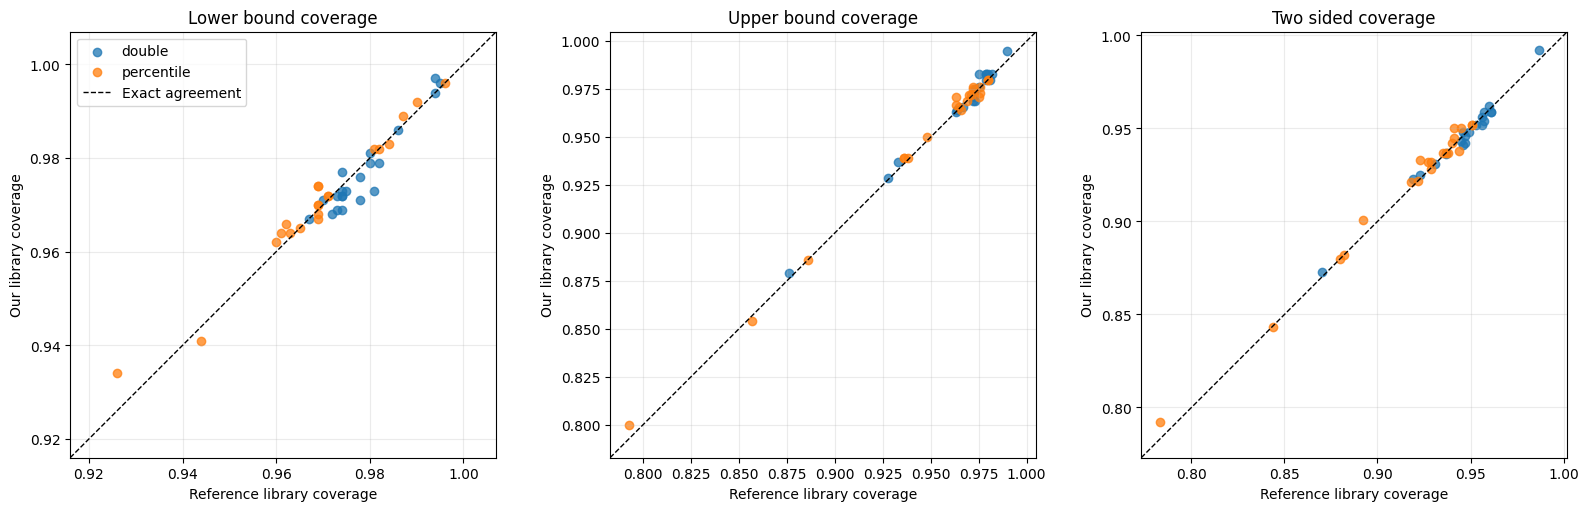

In [133]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5),
    constrained_layout=True,
)

coverage_types = [
    ("lower_coverage", "Lower bound coverage"),
    ("upper_coverage", "Upper bound coverage"),
    ("two_sided_coverage", "Two sided coverage"),
]

for ax, (column, title) in zip(axes, coverage_types):
    x = comparison[f"{column}_unconditional_ref"]
    y = comparison[f"{column}_unconditional_our"]

    for method, group in comparison.groupby("method"):
        ax.scatter(
            group[f"{column}_unconditional_ref"],
            group[f"{column}_unconditional_our"],
            label=method,
            alpha=0.75,
        )

    lower_limit = min(x.min(), y.min()) - 0.01
    upper_limit = max(x.max(), y.max()) + 0.01

    ax.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Exact agreement",
    )

    ax.set(
        xlim=(lower_limit, upper_limit),
        ylim=(lower_limit, upper_limit),
        xlabel="Reference library coverage",
        ylabel="Our library coverage",
        title=title,
        aspect="equal",
    )
    ax.grid(alpha=0.25)

axes[0].legend()